# Machine Learning

## Table of Contents

1. Data Preparation 
   - 1.1 Correlation between features
2. Machine Learning Models
   - 2.1 Random Forest Model (supervised)
     - 2.1.2 RF Model for predictions
   - 2.2 The KNN Model (supervised)
   - 2.3 The KMeans Model (unsupervised)
     - 2.3.1 Elbow Method for the number of clusters selection
     - 2.3.2 The Silhouette Score 
   - 2.4 Hierarchical Clustering
   - 2.5 Sentiment Analysis
   

We proceed to import the libraries and our DataFrame.

In [57]:
# In this sectrion we proceed to import the necesary libraries for our analysis:

#Libraries for general use:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Data Preparation
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder, OneHotEncoder
# 2.1 Random Forest Model (supervised)
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn import metrics
# 2.2 The KNN Model (supervised)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
# 2.3 The KMeans Model (unsupervised)
from sklearn.cluster import KMeans
import mglearn
#2.3.2 The Silhouette Score
from sklearn.metrics import silhouette_score
# 2.4 Hierarchical Clustering
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage
#2.5 Sentiment Analysis
import praw
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer as SIA
from pprint import pprint

# 1. Data Preparation 

In [2]:
crops_prod_EU = pd.read_csv("crops_prod_EU.csv") 
crops_prod_EU

,crops,Country,Alpha-2 code,Alpha-3 code,Year,Area (1000 ha),Standard humidity (%),Main area (1000 ha),Production (1000 t),Yield (tonne/ha
0,C1100,Albania,AL,ALB,2000,112.00,14.0,NaN,341.00,NaN
1,C1100,Belgium,BE,BEL,2000,213.00,14.0,NaN,1675.83,NaN
2,C1100,Slovenia,SI,SVN,2000,38.26,14.0,NaN,162.56,NaN
3,C1100,Bulgaria,BG,BGR,2000,1121.80,14.0,NaN,3485.52,NaN
4,C1100,Sweden,SE,SWE,2000,401.20,14.0,NaN,2371.99,NaN
...,...,...,...,...,...,...,...,...,...,...
836,C1100,Malta,MT,MLT,2023,0.00,14.0,NaN,0.00,NaN
837,C1100,Greece,EL,GRC,2023,247.53,14.0,NaN,780.23,3.15
838,C1100,Estonia,EE,EST,2023,173.57,14.0,NaN,694.12,4.00
839,C1100,France,FR,FRA,2023,4982.50,14.0,NaN,35860.29,7.20


In [3]:
crops_prod_EU.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 841 entries, 0 to 840
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   crops                  841 non-null    object 
 1   Country                841 non-null    object 
 2   Alpha-2 code           841 non-null    object 
 3   Alpha-3 code           841 non-null    object 
 4   Year                   841 non-null    int64  
 5   Area (1000 ha)         833 non-null    float64
 6   Standard humidity (%)  840 non-null    float64
 7   Main area (1000 ha)    0 non-null      float64
 8   Production (1000 t)    841 non-null    float64
 9   Yield (tonne/ha        465 non-null    float64
dtypes: float64(5), int64(1), object(4)
memory usage: 65.8+ KB


In [4]:
data_testing = crops_prod_EU.loc[:, ['Country','Year', 'Area (1000 ha)', "Production (1000 t)"]]
print(data_testing.info())
print("\nNull Values: ")
print(data_testing.isnull().sum())
data_testing 
#RF_testing_data = RF_testing[['Year','VALUE','Mode']]

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 841 entries, 0 to 840
Data columns (total 4 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Country              841 non-null    object 
 1   Year                 841 non-null    int64  
 2   Area (1000 ha)       833 non-null    float64
 3   Production (1000 t)  841 non-null    float64
dtypes: float64(2), int64(1), object(1)
memory usage: 26.4+ KB
None

Null Values: 
Country                0
Year                   0
Area (1000 ha)         8
Production (1000 t)    0
dtype: int64


,Country,Year,Area (1000 ha),Production (1000 t)
0,Albania,2000,112.00,341.00
1,Belgium,2000,213.00,1675.83
2,Slovenia,2000,38.26,162.56
3,Bulgaria,2000,1121.80,3485.52
4,Sweden,2000,401.20,2371.99
...,...,...,...,...
836,Malta,2023,0.00,0.00
837,Greece,2023,247.53,780.23
838,Estonia,2023,173.57,694.12
839,France,2023,4982.50,35860.29


In [5]:
null_values = data_testing [data_testing ["Area (1000 ha)"].isnull()]
null_values

,Country,Year,Area (1000 ha),Production (1000 t)
319,Turkey,2009,NaN,20520.00
334,Malta,2010,NaN,0.00
342,Latvia,2010,NaN,989.40
386,Malta,2011,NaN,0.00
436,Malta,2012,NaN,0.00
447,Malta,2013,NaN,0.00
487,Malta,2014,NaN,0.00
513,Albania,2014,NaN,276.74


In [6]:
data_testing = data_testing.dropna()
print(data_testing.isnull().sum())

Country                0
Year                   0
Area (1000 ha)         0
Production (1000 t)    0
dtype: int64


In [7]:
o_encoder = OrdinalEncoder()
l_encoder = LabelEncoder()

data_testing["Country"] = l_encoder.fit_transform(data_testing["Country"])
data_testing

C:\Users\gus_d\AppData\Local\Temp\ipykernel_29056\3411896862.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_testing["Country"] = l_encoder.fit_transform(data_testing["Country"])


,Country,Year,Area (1000 ha),Production (1000 t)
0,0,2000,112.00,341.00
1,2,2000,213.00,1675.83
2,32,2000,38.26,162.56
3,4,2000,1121.80,3485.52
4,34,2000,401.20,2371.99
...,...,...,...,...
836,22,2023,0.00,0.00
837,13,2023,247.53,780.23
838,9,2023,173.57,694.12
839,11,2023,4982.50,35860.29


## 1.1 Correlation between features

In [8]:
data_testing[data_testing.columns[:]].corr()['Production (1000 t)'][:]

Country                0.085081
Year                  -0.003959
Area (1000 ha)         0.855193
Production (1000 t)    1.000000
Name: Production (1000 t), dtype: float64

[[ 1.          0.01831219  0.21770635  0.08508132]
 [ 0.01831219  1.         -0.03682585 -0.00395903]
 [ 0.21770635 -0.03682585  1.          0.85519346]
 [ 0.08508132 -0.00395903  0.85519346  1.        ]]


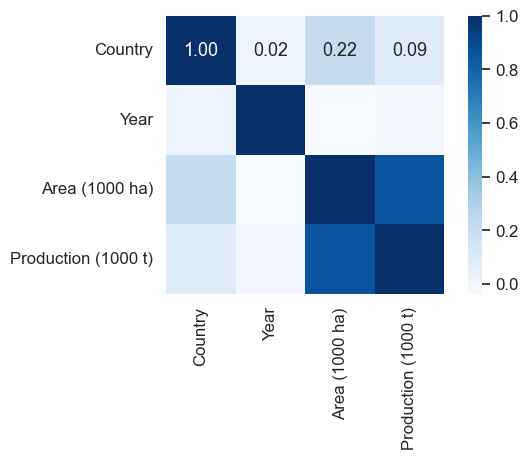

In [9]:
cols = data_testing.columns

# Initialise an object (cm) using np object
cm = np.corrcoef(data_testing[cols].values.T)

# Set the font size of the plot
sns.set(font_scale = 1.1)

hm = sns.heatmap(cm, 
            cbar=True,
            annot=True, 
            square=True,
            cmap = "Blues",
            fmt='.2f',
            annot_kws={'size': 13},
            yticklabels=cols,
            xticklabels=cols)

plt.tight_layout()
# plt.savefig('./figures/corr_mat.png', dpi=300)
print(cm)
plt.show()

C:\Users\gus_d\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\gus_d\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


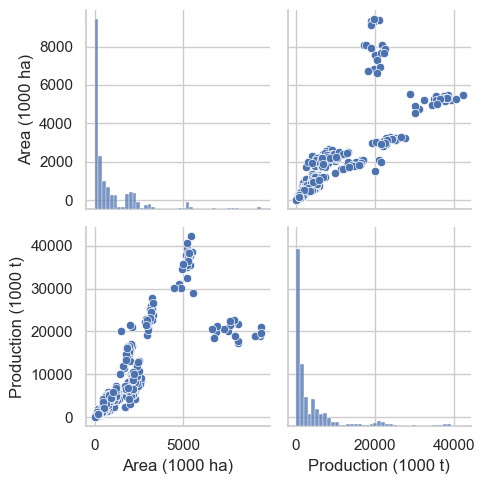

In [10]:
# import the libraries for the plot
%matplotlib inline

# Set the style for the plot using swaborn library
sns.set(style='whitegrid', context='notebook')

# Consider the following columns from the entire dataset
cols = ['Area (1000 ha)', 'Production (1000 t)']

# Display the pairplot using the above-mentioned columns
sns.pairplot(data_testing[cols], height = 2.5)

plt.tight_layout()

# pltpy.savefig('./figures/scatter.png', dpi=300)
plt.show()

# 2. Machine Learning Models

---

## 2.1 Random Forest Model (supervised)
We are building a model on data_testing dataset. We have encoded the country names, so that, we can use as the target for this model. Start by loading the data_testing saved from the first Jupyter Notebook "Analysing Ireland and the EU Agricultural data (Data Preparation and Statistics)".

In [11]:
data_testing.columns

Index(['Country', 'Year', 'Area (1000 ha)', 'Production (1000 t)'], dtype='object')

In [12]:
# Import train_test_split function

X = data_testing[['Year', 'Area (1000 ha)', 'Production (1000 t)']] # Features
y = data_testing['Country']  # Labels

# Split dataset into training set and test set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 0) 
# 70% training and 30% test

In [13]:
#Import Random Forest Model

#Create a Gaussian Classifier
clf = RandomForestClassifier(n_estimators = 100)

#Train the model using the training sets y_pred=clf.predict(X_test)
clf.fit(X_train,y_train)

y_pred = clf.predict(X_test)

#Train the model using the training sets y_pred=clf.predict(X_test)
clf.fit(X_train,y_train)

RandomForestClassifier()

In [14]:
#Import scikit-learn metrics module for accuracy calculation

# Model Accuracy, how often is the classifier correct?
print("Accuracy:",metrics.accuracy_score(y_test, y_pred))

Accuracy: 0.652


After splitting our data into train data and test data and use the RandomForestClassifier() we got and accuracy of 0.652.

In [15]:
feature_imp = pd.Series(clf.feature_importances_,index= data_testing.columns[1:4]).sort_values(ascending=False)
feature_imp

Area (1000 ha)         0.455502
Production (1000 t)    0.418464
Year                   0.126034
dtype: float64

We can visualize the feature importance. Visualizations are easy to understand and interpretable.

For visualization, we can use a combination of matplotlib and seaborn. Because seaborn is built on top of matplotlib, it offers a number of customized themes and provides additional plot types. Matplotlib is a superset of seaborn and both are equally important for good visualizations.

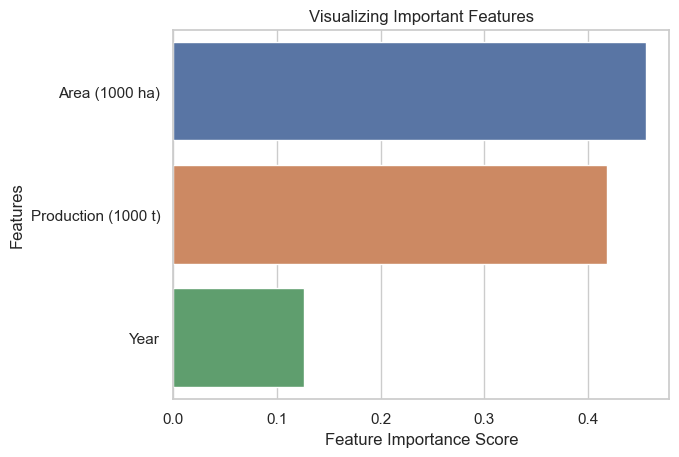

In [16]:
# import the libraries for the plot
%matplotlib inline
# Creating a bar plot
sns.barplot(x=feature_imp, y=feature_imp.index)
# Add labels to your graph
plt.xlabel('Feature Importance Score')
plt.ylabel('Features')
plt.title("Visualizing Important Features")
#pltpy.legend()
plt.show()

Generating the Model on Selected Features.

We can remove the "Year" feature because it has very low importance, and select the 2 remaining features.

In [17]:
# Import train_test_split function

X = data_testing[[ 'Area (1000 ha)', 'Production (1000 t)']]  # Features
y = data_testing['Country']  # Labels

# Split dataset into training set and test set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 0) 
# 70% training and 30% test

In [18]:
#Create a Gaussian Classifier
clf = RandomForestClassifier(n_estimators = 100)

#Train the model using the training sets y_pred=clf.predict(X_test)
clf.fit(X_train,y_train)

y_pred = clf.predict(X_test)

#Train the model using the training sets y_pred=clf.predict(X_test)
clf.fit(X_train,y_train)


RandomForestClassifier()

In [19]:
# Model Accuracy, how often is the classifier correct?
print("Accuracy:",metrics.accuracy_score(y_test, y_pred))

Accuracy: 0.744


### 2.1.2 RF Model for predictions

In [20]:
 data_testing.loc[[0, 2, 839]]

,Country,Year,Area (1000 ha),Production (1000 t)
0,0,2000,112.00,341.00
2,32,2000,38.26,162.56
839,11,2023,4982.50,35860.29


We can also make a prediction for a single item, for example:

Area (1000 ha) = 112.00  Production (1000 t) = 341.00
Area (1000 ha) = 38.26   Production (1000 t) = 162.56
Area (1000 ha) = 4982.50 Production (1000 t) = 35860.29

Now you can predict the country according to the Area and Production

In [21]:
print(clf.predict([[112.00, 341.00]]), 
      clf.predict([[38.26, 162.56]]), 
      clf.predict([[4982.50, 35860.29]],))

labels = pd.DataFrame({'Country': l_encoder.classes_, 
                       'l_encoder code': l_encoder.transform(l_encoder.classes_)})

[0] [32] [11]


C:\Users\gus_d\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\gus_d\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\gus_d\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [22]:
predicted_labels = labels[labels['l_encoder code'].isin([0, 32, 11])]
predicted_labels 

,Country,l_encoder code
0,Albania,0
11,France,11
32,Slovenia,32


In [23]:
predictions = crops_prod_EU[crops_prod_EU['Production (1000 t)'].isin([341.00, 162.56, 35860.29])]
predictions

,crops,Country,Alpha-2 code,Alpha-3 code,Year,Area (1000 ha),Standard humidity (%),Main area (1000 ha),Production (1000 t),Yield (tonne/ha
0,C1100,Albania,AL,ALB,2000,112.00,14.0,NaN,341.00,NaN
2,C1100,Slovenia,SI,SVN,2000,38.26,14.0,NaN,162.56,NaN
839,C1100,France,FR,FRA,2023,4982.50,14.0,NaN,35860.29,7.2


Once we used the encoder to transform our categorical feature and applied the Random Forest model to predict the labels for the countries, we got an accuracy between 0.6 and 0.7, which is not bad considering the number of labels that we have, the model performed well with the predictions, by modifying the test size to 0.2 or 0.1 we can get a better accuracy but is not a big difference, the max value is 0.66, using parameter test_size = 0.1. We can also use clustering models for our countries resulting by the area and production comparisson, this could tell us how our data can be grouped.

----

## 2.2 The KNN Model (supervised)
After loading, analyzing and preprocessing of the data, we can feed the data into the KNN model. To do this, we  use sklearn's inbuilt function neighbors which has a class called KNeigborsClassifier in it. Let's start by importing the classifier.

### KNN Distance Metrics

How do we measure distance?

* Euclidian
$$
d_{euclidean} = \sqrt{\sum_{i=1}^{n}{(x_i - y_i)^2}}
$$

* Manhattan
$$
d_{manhattan} = \sum_{i=1}^{n}{|x_i - y_i|}
$$

* Minkowski (default)
$$
d_{minkowski} = (\sum_{i=1}^{n}{|x_i - y_i|^p})^{\frac{1}{p}}
$$

In [24]:
data_testing 

,Country,Year,Area (1000 ha),Production (1000 t)
0,0,2000,112.00,341.00
1,2,2000,213.00,1675.83
2,32,2000,38.26,162.56
3,4,2000,1121.80,3485.52
4,34,2000,401.20,2371.99
...,...,...,...,...
836,22,2023,0.00,0.00
837,13,2023,247.53,780.23
838,9,2023,173.57,694.12
839,11,2023,4982.50,35860.29


In [25]:
# Import train_test_split function

X = data_testing[[ 'Area (1000 ha)', 'Production (1000 t)']]  # Features
y = data_testing['Country']  # Labels

# Split dataset into training set and test set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 0) 
# 70% training and 30% test

In [26]:
#Import the KNeighborsClassifier from sklearn.neighbors

# build the clustering model
knn = KNeighborsClassifier (n_neighbors = 5)
knn.fit(X_train, y_train)

KNeighborsClassifier()

In [27]:
knn.score(X_test,y_test)

0.64

In order to decide the best value for hyperparameter k (number of neighbors), We need to train and test your model on 10 different k values and finally use the one that gives the best results.

Let's initialize a variable neighbors(k) which will have values ranging from 1-9 and two numpy zero matrices namely train_accuracy and test_accuracy each for training and testing accuracy. We need them later to plot a graph to choose the best neighbor value.

In [28]:
neighbors = np.arange(1, 15)                  # number of neighbors
train_accuracy = np.zeros(len(neighbors))    # Declare and initialise the matrix
test_accuracy = np.zeros(len(neighbors))     # Declare and initialise the matrix

The following piece of code is where all the processing will happen. We enumerate over all the nine neighbor values and for each neighbor we then predict both on training and testing data. Finally, store the accuracy in the train_accuracy and test_accuracy numpy arrays.

In [29]:
for i,k in enumerate(neighbors):                          # for loop that checks the model for neighbor values 1, 2, 3, ..., 9
    knn = KNeighborsClassifier(n_neighbors = k)           # Initialise an object knn using KNeighborsClassifier method

    #Fit the model
    knn.fit(X_train, y_train)                    # Call fit method to implement the ML KNeighborsClassifier model

    #Compute accuracy on the training set
    train_accuracy[i] = knn.score(X_train, y_train)   # Save the score value in the train_accuracy array

    #Compute accuracy on the test set
    test_accuracy[i] = knn.score(X_test,y_test)      # Save the score value in the train_accuracy array

We plot the training and testing accuracy using matplotlib, with accuracy vs. varying number of neighbors graph. Now we can choose the best k value at which our model performs the best.

In [30]:
test_accuracy

array([0.66 , 0.624, 0.664, 0.652, 0.64 , 0.624, 0.628, 0.612, 0.592,
       0.58 , 0.612, 0.588, 0.588, 0.556])

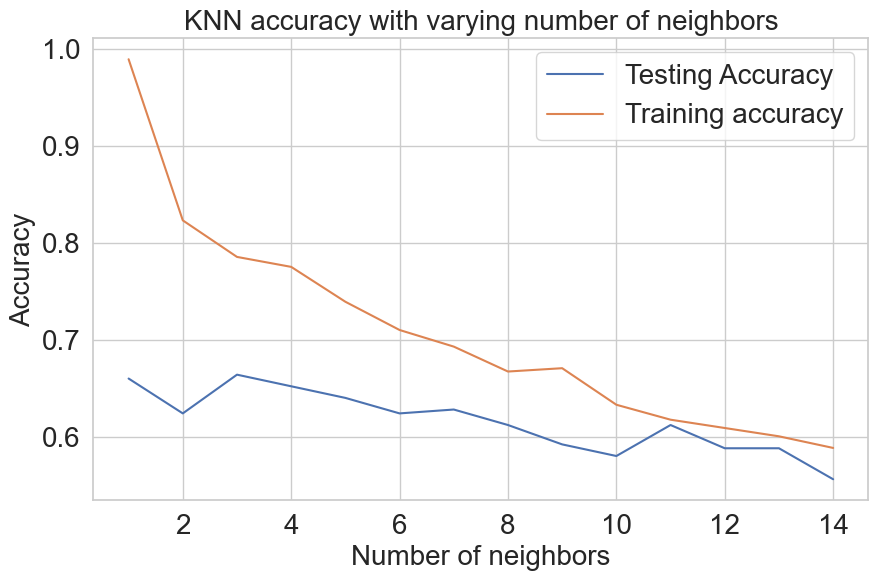

In [31]:
# Delcare the size of the array
plt.figure(figsize = (10, 6))
plt.title('KNN accuracy with varying number of neighbors', fontsize = 20)
plt.plot(neighbors, test_accuracy, label = 'Testing Accuracy')
plt.plot(neighbors, train_accuracy, label = 'Training accuracy')
plt.legend(prop = {'size': 20})
plt.xlabel('Number of neighbors', fontsize = 20)
plt.ylabel('Accuracy', fontsize = 20)
plt.xticks(fontsize = 20)
plt.yticks(fontsize = 20)
plt.show()

In [61]:
# Declare and initialise an object 'KNeighborsClassifier' with 3 neighbors
knn = KNeighborsClassifier(n_neighbors = 3)

# Fit the model
knn.fit(X_train, y_train) 

# Compute accuracy on the training set
train_accuracy = knn.score(X_train, y_train) 

# Compute accuracy on the test set
test_accuracy = knn.score(X_test, y_test)

# Display the test accuracy
print(test_accuracy)

0.664


### Confusion Matrix
A confusion matrix is mainly used to describe the performance of ML model on the test data for which the true values or labels are known. Scikit-learn provides a function that calculates the confusion matrix for you.

In [33]:
# import library for confusion matrix

# Predict the results by calling a method 'predict()'
prediction = knn.predict(X_test)

# Display the confusion matrix
confusion_matrix(y_test, prediction)

array([[1, 0, 0, ..., 0, 0, 0],
       [0, 5, 0, ..., 0, 0, 0],
       [0, 0, 9, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 3, 0, 0],
       [0, 0, 0, ..., 0, 7, 0],
       [0, 0, 0, ..., 0, 0, 6]], dtype=int64)

In [34]:
# import the library classification_report

# Display the report
print(classification_report(y_test, prediction))

              precision    recall  f1-score   support

           0       0.08      0.25      0.12         4
           1       0.83      0.83      0.83         6
           2       1.00      1.00      1.00         9
           3       0.17      0.11      0.13         9
           4       0.43      0.50      0.46         6
           5       0.60      0.60      0.60         5
           6       1.00      1.00      1.00         6
           7       0.64      0.78      0.70         9
           8       0.86      1.00      0.92         6
           9       0.12      0.14      0.13         7
          10       0.55      0.60      0.57        10
          11       1.00      1.00      1.00        10
          12       1.00      1.00      1.00         7
          13       1.00      0.62      0.77         8
          14       0.44      0.67      0.53         6
          15       1.00      1.00      1.00         1
          16       1.00      0.75      0.86         8
          17       0.75    

## 2.3 The KMeans Model (unsupervised)
After loading, analysing and preprocessing of the data, we can feed the data into the KNN model. To do this, we use sklearn's inbuilt function neighbors which has a class called KNeigborsClassifier in it. Let's start by importing the classifier.

In [35]:
#from sklearn.cluster import KMeans

# build the clustering model
kmeans = KMeans(n_clusters = 3, random_state = 38) #The initial number of clusters is arbitrary.
kmeans.fit(X)

C:\Users\gus_d\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(


KMeans(n_clusters=3, random_state=38)

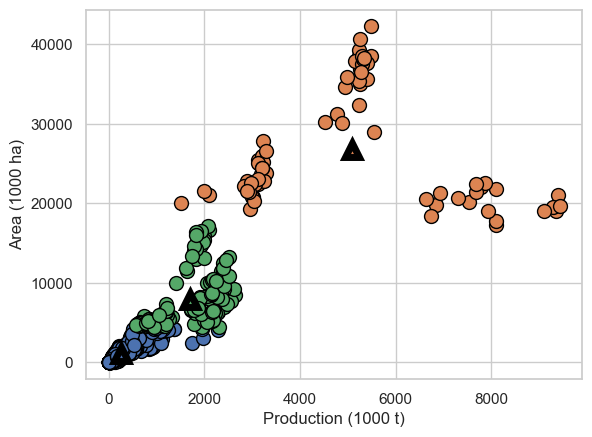

In [36]:
#import mglearn
# Graficar usando los datos del DataFrame
mglearn.discrete_scatter(X['Area (1000 ha)'], X['Production (1000 t)'] , kmeans.labels_, markers='o')
mglearn.discrete_scatter(
    kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], [0, 1, 2], markers='^', markeredgewidth=5)
plt.xlabel('Production (1000 t)')
plt.ylabel('Area (1000 ha)')
plt.show()

### 2.3.1 Elbow Method for the number of clusters selection
The elbow method determines the optimal number of clusters (K) through a graphical approach. It works by calculating the within-cluster sum of squares (WCSS), which is the sum of the squared distances between points within a cluster and the cluster's centroid.

C:\Users\gus_d\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(


51410837873.64017


C:\Users\gus_d\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(


12044194557.892485


C:\Users\gus_d\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(


...

821503702.4632037


C:\Users\gus_d\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(


621910132.9274228


C:\Users\gus_d\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(


505576422.41102713


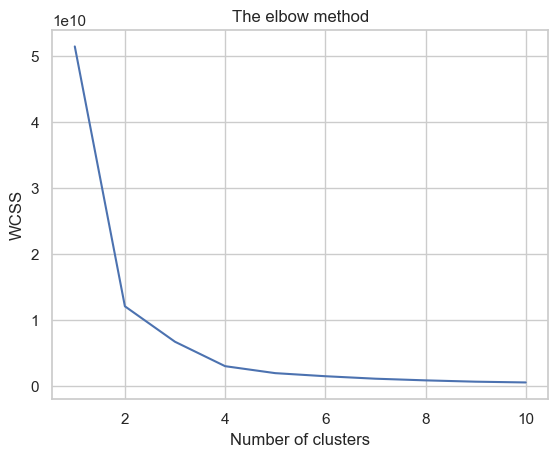

In [37]:
# Finding the optimum number of clusters for k-means classification
#from sklearn.cluster import KMeans
wcss = []                  # Declare an array

# Set the loop from the minimum and maximum values
for i in range(1, 11):
    kmeans = KMeans(n_clusters = i, max_iter = 300, n_init = 10, random_state = 0)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)
    print(kmeans.inertia_)
# inertia_float: Sum of squared distances of samples to their closest cluster center.

# Plotting the results onto a line graph, allowing us to observe 'The elbow'
plt.plot(range(1, 11), wcss)
plt.title('The elbow method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')    # within cluster sum of squares
plt.show()

The curve looks like an elbow. In the above plot, the elbow could be at k = 2 or k = 4 .The Sum of squared distances falls suddenly after k = 2, indicating the optimal k for this dataset could be either 2 or 4, where biggest difference occurs.

C:\Users\gus_d\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
C:\Users\gus_d\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(


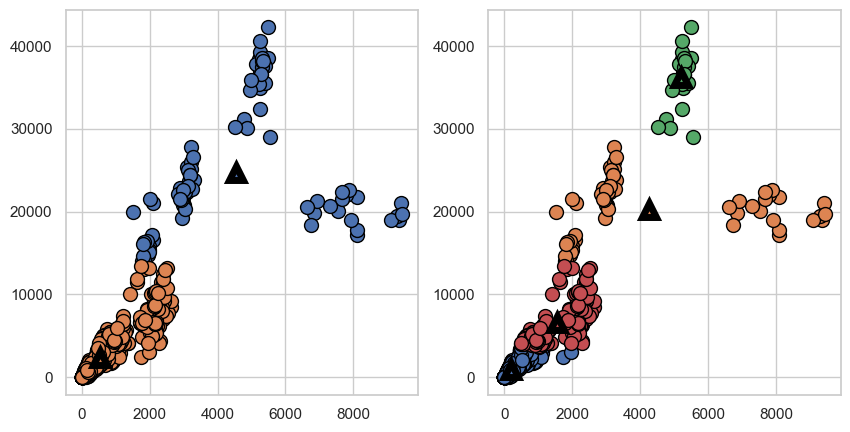

In [38]:
fig, axes = plt.subplots(1, 2, figsize = (10, 5))

# using 2 cluster centers:
kmeans1 = KMeans(n_clusters =  2)
kmeans1.fit(X)
assignments = kmeans1.labels_
mglearn.discrete_scatter(X['Area (1000 ha)'], 
                         X['Production (1000 t)'] , 
                         kmeans1.labels_, ax = axes[0], markers='o')
mglearn.discrete_scatter(
    kmeans1.cluster_centers_[:, 0], 
    kmeans1.cluster_centers_[:, 1], 
    [0, 1], markers='^', ax = axes[0], markeredgewidth=5)


# using 4 cluster centers:
kmeans2 = KMeans(n_clusters = 4)
kmeans2.fit(X)
assignments = kmeans2.labels_
mglearn.discrete_scatter(X['Area (1000 ha)'], 
                         X['Production (1000 t)'] , 
                         kmeans2.labels_, ax = axes[1], markers='o')
mglearn.discrete_scatter(
    kmeans2.cluster_centers_[:, 0], 
    kmeans2.cluster_centers_[:, 1], 
    [0, 1, 2, 3], markers='^', ax = axes[1], markeredgewidth=5)

Unfortunately, as in this case, the elbow method often does not present a clear inflection point, making it difficult to identify the correct number of clusters (K). As a result, it is easy to choose an incorrect value for K.

Using the Silhouette score can help to identify the optimal number of clusters by evaluating the cohesion within clusters and the separation between clusters.

## 2.3.2 The Silhouette Score 

The Silhouette score is a highly useful technique for determining the optimal number of clusters (K) when the elbow method fails to reveal a clear elbow point.

"The Silhouette Coefficient is calculated using the mean intra-cluster distance (a) and the mean nearest-cluster distance (b) for each sample. The Silhouette Coefficient for a sample is (b - a) / max(a, b). To clarify, b is the distance between a sample and the nearest cluster that the sample is not a part of. Note that Silhouette Coefficient is only defined if number of labels is 2 <= n_labels <= n_samples - 1.

This function returns the mean Silhouette Coefficient over all samples. To obtain the values for each sample, use silhouette_samples.

The best value is 1 and the worst value is -1. Values near 0 indicate overlapping clusters. Negative values generally indicate that a sample has been assigned to the wrong cluster, as a different cluster is more similar".

Available at: https://scikit-learn.org/stable/modules/generated/sklearn.metrics.silhouette_score.html

In resume: 

   -   1: Points are perfectly assigned in a cluster and clusters are easily distinguishable.
   -   0: Clusters are overlapping.
   -  -1: Points are wrongly assigned in a cluster.

C:\Users\gus_d\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
C:\Users\gus_d\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
C:\Users\gus_d\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
C:\Users\gus_d\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Window

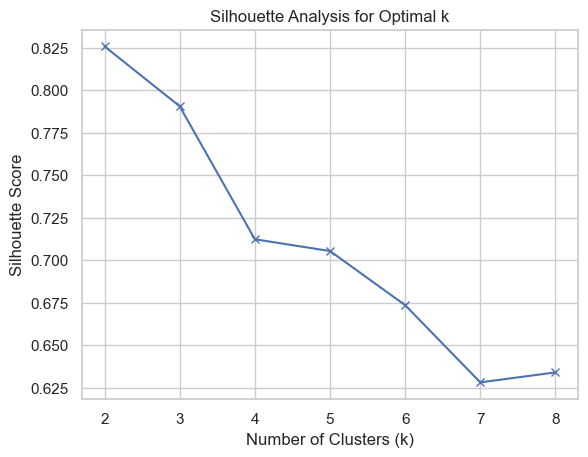

Silhouette Score for 2 clusters: 0.826
Silhouette Score for 3 clusters: 0.790
Silhouette Score for 4 clusters: 0.712
Silhouette Score for 5 clusters: 0.705


In [39]:
#from sklearn.metrics import silhouette_score

# Instantiate the KMeans models
km1 = KMeans(n_clusters = 2, random_state=42)
km2 = KMeans(n_clusters = 3, random_state=42)
km3 = KMeans(n_clusters = 4, random_state=42)
km4 = KMeans(n_clusters = 5, random_state=42)

# Fit the KMeans model
km1.fit_predict(X)
km2.fit_predict(X)
km3.fit_predict(X)
km4.fit_predict(X)

# Calculate Silhoutte Score
score1 = silhouette_score(X, km1.labels_, metric='euclidean')
score2 = silhouette_score(X, km2.labels_, metric='euclidean')
score3 = silhouette_score(X, km3.labels_, metric='euclidean')
score4 = silhouette_score(X, km4.labels_, metric='euclidean')


# Print the score
#print('Silhouetter Score for 2 clusters: %.3f' % score1)
#print('Silhouetter Score for 3 clusters: %.3f' % score2)
#print('Silhouetter Score for 4 clusters: %.3f' % score3)
#print('Silhouetter Score for 5 clusters: %.3f' % score4)


#Plotting the results:
range_n_clusters = [2, 3, 4, 5, 6, 7, 8]
silhouette_avg = []

for num_clusters in range_n_clusters:
    # Initialize kmeans
    kmeans = KMeans(n_clusters=num_clusters, random_state=42)
    kmeans.fit(X)
    cluster_labels = kmeans.labels_

    # Calculate silhouette score
    silhouette_avg_score = silhouette_score(X, cluster_labels)
    silhouette_avg.append(silhouette_avg_score)

# Plot silhouette scores
plt.plot(range_n_clusters, silhouette_avg, 'bx-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Analysis for Optimal k')
plt.show()

print('Silhouette Score for 2 clusters: %.3f' % score1)
print('Silhouette Score for 3 clusters: %.3f' % score2)
print('Silhouette Score for 4 clusters: %.3f' % score3)
print('Silhouette Score for 5 clusters: %.3f' % score4)

After applying the Silhouette Score method, the optimal number of clusters is k = 2.

# 2.4 Hierarchical Clustering

"Hierarchical clustering is a general family of clustering algorithms that build nested clusters by merging or splitting them successively. This hierarchy of clusters is represented as a tree (or dendrogram). The root of the tree is the unique cluster that gathers all the samples, the leaves being the clusters with only one sample. It’s possible to visualize the tree representing the hierarchical merging of clusters as a dendrogram. Visual inspection can often be useful for understanding the structure of the data, though more so in the case of small sample sizes".

A dendrogram is a tree-like diagram that records the sequences of merges or splits. It provides a graphical representation of the hierarchy of clusters. 

Available at: https://scikit-learn.org/stable/modules/clustering.html#hierarchical-clustering

To ease the process in case of modifications we can create next variables:

In [40]:
df =  data_testing   #dataframe that we are using for the model.
column_x = data_testing['Area (1000 ha)']
title_x = 'Area (1000 ha)'
column_y = data_testing['Production (1000 t)']
title_y = 'Production (1000 t)'

We can now use the Agglomerative Clustering model to have another approach using the optimal number of clusters previously found with the Silhouette Score method.

In [41]:
#from sklearn.cluster import AgglomerativeClustering

# Initilise the cluster using a method AgglomerativeClustering
cluster = AgglomerativeClustering(n_clusters= 2, metric='euclidean', linkage='ward') 

clusters_parameter = 2

# Call the method for the training
cluster.fit_predict(df)

array([0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

Once we verified that the model worked, we can compare different metrics and analyse both model and dendograms.

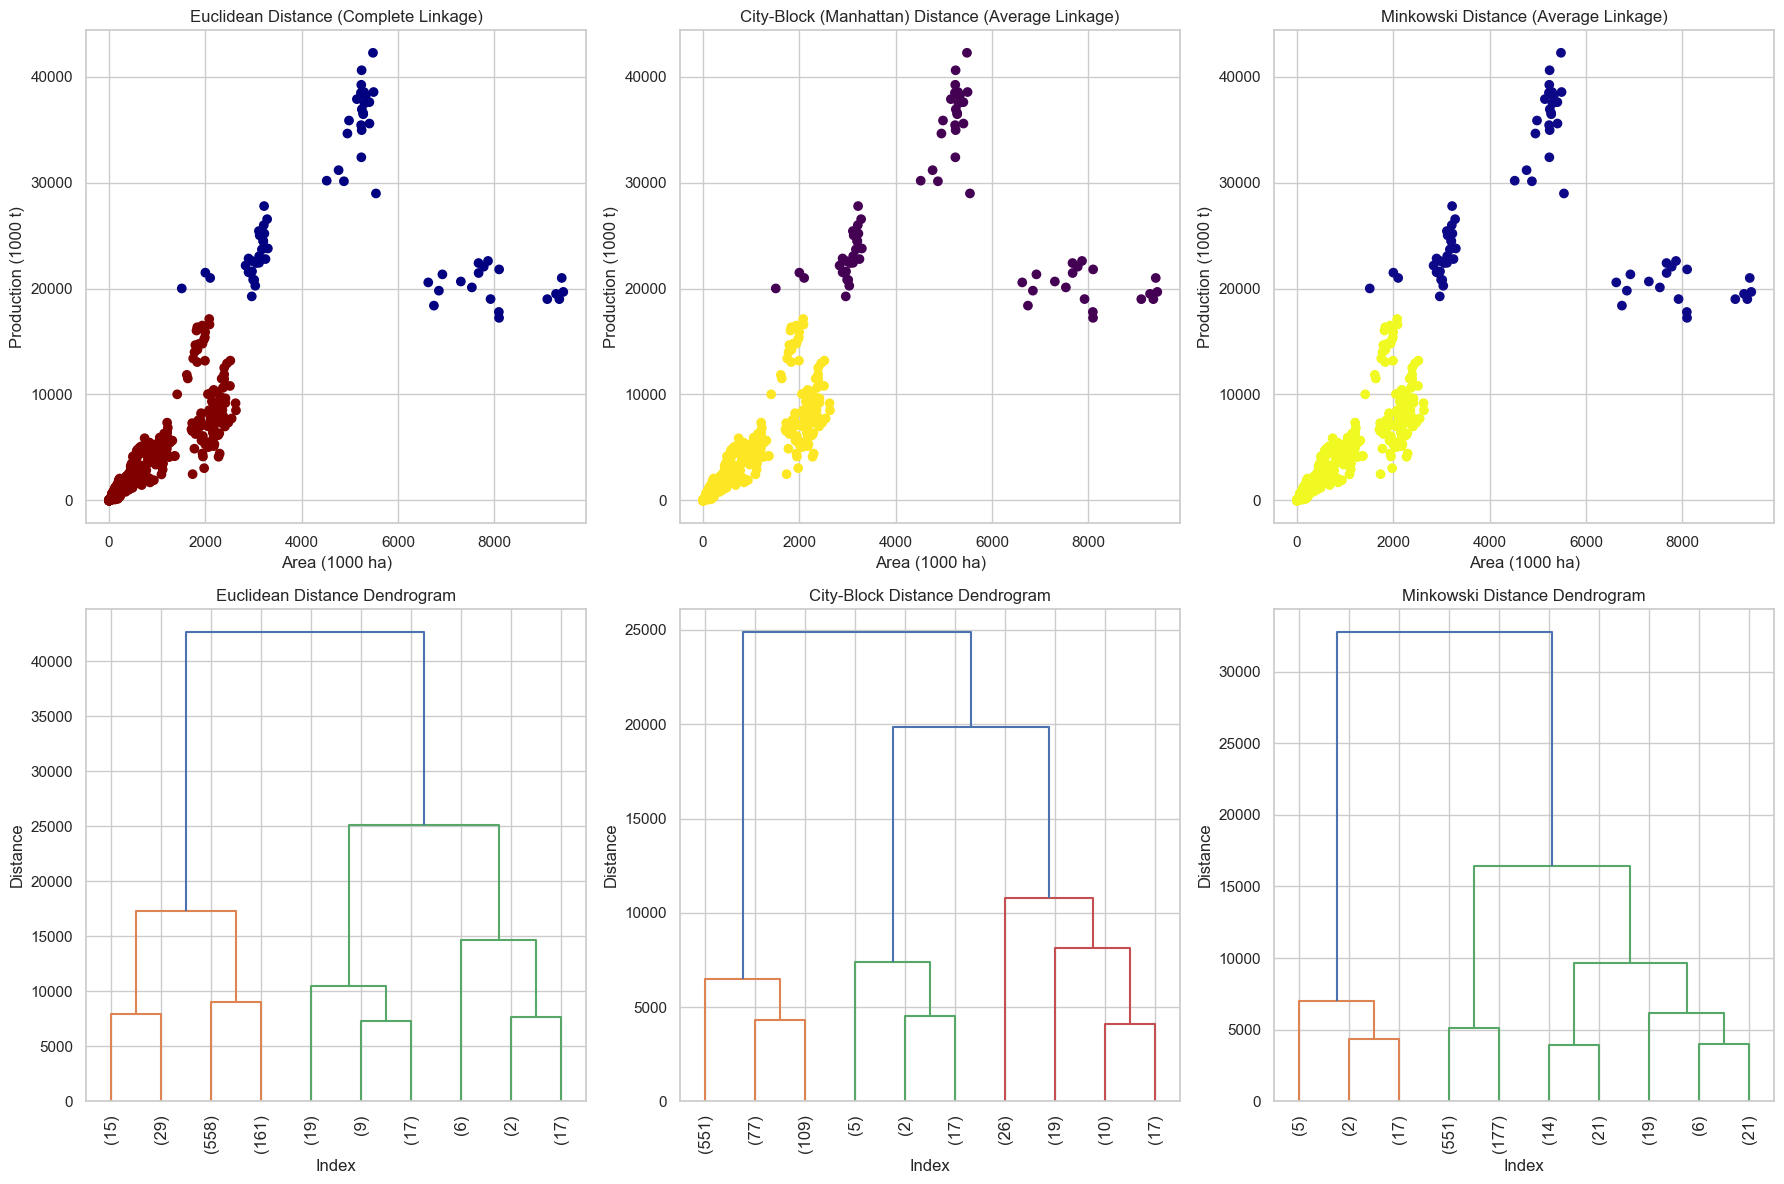

In [42]:
#from sklearn.cluster import AgglomerativeClustering
#import matplotlib.pyplot as plt
#from scipy.cluster.hierarchy import dendrogram, linkage

# Initialize the cluster using AgglomerativeClustering
# For Euclidean distance
cluster_euclidean = AgglomerativeClustering(clusters_parameter, metric='euclidean', linkage='complete')  
# For City-Block (Manhattan) distance
cluster_city_block = AgglomerativeClustering(clusters_parameter, metric='manhattan', linkage='complete')
# For Minkowski distance
cluster_minkowski = AgglomerativeClustering(clusters_parameter, metric='minkowski', linkage='complete')  

# Call the method for training
labels_euclidean = cluster_euclidean.fit_predict(df)
labels_city_block = cluster_city_block.fit_predict(df)
labels_minkowski = cluster_minkowski.fit_predict(df)

# Compute linkage matrices
Z_euclidean = linkage(df, method='complete', metric='euclidean')
Z_city_block = linkage(df, method='average', metric='cityblock')
Z_minkowski = linkage(df, method='average', metric='minkowski')

# Set the size of the figure 
plt.figure(figsize=(18, 12))

# Plot for Euclidean distance
plt.subplot(2, 3, 1)
plt.title('Euclidean Distance (Complete Linkage)')
plt.scatter(column_x, column_y, c=labels_euclidean,  cmap='jet')
plt.xlabel(title_x)
plt.ylabel(title_y)

# Plot dendrogram for Euclidean distance
plt.subplot(2, 3, 4)
dendrogram(Z_euclidean, leaf_rotation=90, truncate_mode='lastp', p=10)  # Show only 10 labels
plt.title('Euclidean Distance Dendrogram')
plt.xlabel('Index')
plt.ylabel('Distance')

# Plot for City-Block (Manhattan) distance
plt.subplot(2, 3, 2)
plt.title('City-Block (Manhattan) Distance (Average Linkage)')
plt.scatter(column_x, column_y, c=labels_city_block,  cmap='viridis')
plt.xlabel(title_x)
plt.ylabel(title_y)

# Plot dendrogram for City-Block distance
plt.subplot(2, 3, 5)
dendrogram(Z_city_block, leaf_rotation=90, truncate_mode='lastp', p=10)  # Show only 10 labels
plt.title('City-Block Distance Dendrogram')
plt.xlabel('Index')
plt.ylabel('Distance')

# Plot for Minkowski distance
plt.subplot(2, 3, 3)
plt.title('Minkowski Distance (Average Linkage)')
plt.scatter(column_x, column_y, c=labels_minkowski,  cmap='plasma') 
plt.xlabel(title_x)
plt.ylabel(title_y)

# Plot dendrogram for Minkowski distance
plt.subplot(2, 3, 6)
dendrogram(Z_minkowski, leaf_rotation=90, truncate_mode='lastp', p=10)  # Show only 10 labels
plt.title('Minkowski Distance Dendrogram')
plt.xlabel('Index')
plt.ylabel('Distance')

plt.tight_layout()
plt.show()

After plotting, notice how the clusters are separated approximately at a level of production of 20000 (scale of 1000t), where the outliers found in the Data Preparation notebook  such as France, Germany and Turkey are located, showing their high level of production compared with the other countries located in the other cluster (under 20000). 

In order to have a better of understanding  of the situation and perhaps some concerns in regards of the wheat production in Europe we can use the praw and nltk libraries to perform a sentiment analysis of people's opinion within the topic.

# 2.5 Sentiment Analysis

Getting acces to Reddit by creating an app in the platform.

In [43]:
#import praw
#import nltk

user_agent =  #'Insert your user agent',
reddit = praw.Reddit(
    client_id =  #'Insert your client id',
    client_secret =  #'Insert your client secret',
    user_agent = user_agent
)

Accessing to an specific post with its URL and getting the comments.

In [44]:
post_url = 'https://www.reddit.com/r/europe/comments/19c976p/the_eu_has_been_the_2nd_biggest_wheat_exporter/'

submission = reddit.submission(url = post_url)
comments = set()
submission.comments.replace_more(limit=None)
for comment in submission.comments.list():
    comments.add(comment.body)
print(len(comments))

80


We can use the pandas library to create a DataFrame.

In [45]:
df_comments = pd.DataFrame(comments)
df_comments.head()

,0
0,sad
1,At least three wheats
2,Definitely. They have even before the war been...
3,Russia stole enormous amount of wheat from Ukr...
4,I don't understand what you're trying to say? ...


In [46]:
#df_comments.to_csv('headlines.csv', header = False, encoding = 'utf-8', index = False)

In [47]:
nltk.download('vader_lexicon') #Need to download the 'vader_lexicon' package

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\gus_d\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

The SentimentIntensityAnalyzer from the nltk.sentiment.vader library is going to help us to assing a score for each comment in the post.

In [48]:
#from nltk.sentiment.vader import SentimentIntensityAnalyzer as SIA
#from pprint import pprint

sia = SIA()
results = []

for line in comments:
    subreddit_score = sia.polarity_scores(line) # -> dict
    subreddit_score['comment'] = line
    results.append(subreddit_score)
    
pprint(results[:3], width = 100)

[{'comment': 'sad', 'compound': -0.4767, 'neg': 1.0, 'neu': 0.0, 'pos': 0.0},
 {'comment': 'At least three wheats', 'compound': 0.0, 'neg': 0.0, 'neu': 1.0, 'pos': 0.0},
 {'comment': 'Definitely. They have even before the war been behind in productivity. With '
             'modernisation their output will increase enormously.',
  'compound': 0.0258,
  'neg': 0.163,
  'neu': 0.628,
  'pos': 0.209}]


Creating a new dataframe including the score columns.

In [49]:
df_comments = pd.DataFrame.from_records(results)
print(df_comments.shape)
df_comments.head()

(80, 5)


,neg,neu,pos,compound,comment
0,1.000,0.000,0.000,-0.4767,sad
1,0.000,1.000,0.000,0.0000,At least three wheats
2,0.163,0.628,0.209,0.0258,Definitely. They have even before the war been...
3,0.000,1.000,0.000,0.0000,Russia stole enormous amount of wheat from Ukr...
4,0.229,0.771,0.000,-0.5940,I don't understand what you're trying to say? ...


We can use the positive, negative and neutral scores to add a label for each comment to summarize de sentiment value.

In [50]:
df_comments ['label'] = 0
df_comments .loc[df_comments ['compound'] >  0.2, 'label'] =  1
df_comments .loc[df_comments ['compound'] < -0.2, 'label'] = -1
df_comments .head()

,neg,neu,pos,compound,comment,label
0,1.000,0.000,0.000,-0.4767,sad,-1
1,0.000,1.000,0.000,0.0000,At least three wheats,0
2,0.163,0.628,0.209,0.0258,Definitely. They have even before the war been...,0
3,0.000,1.000,0.000,0.0000,Russia stole enormous amount of wheat from Ukr...,0
4,0.229,0.771,0.000,-0.5940,I don't understand what you're trying to say? ...,-1


In [51]:
comments_summary = df_comments[['comment', 'label']] #Reducing the dataframe to have the key info.
comments_summary.head()

,comment,label
0,sad,-1
1,At least three wheats,0
2,Definitely. They have even before the war been...,0
3,Russia stole enormous amount of wheat from Ukr...,0
4,I don't understand what you're trying to say? ...,-1


In [52]:
#comments_summary.to_csv('reddit_headlines_labels.csv', encoding = 'utf-8', index = False)

Now we can use the value_counts() function to get a summary of the positive, negative and neutral values.

In [53]:
comments_summary.label.value_counts()

label
 0    35
 1    27
-1    18
Name: count, dtype: int64

In [54]:
comments_summary.label.value_counts(normalize = True) * 100 #Transforming to percentage

label
 0    43.75
 1    33.75
-1    22.50
Name: proportion, dtype: float64

Here we have some examples of both, positive and negative comments according to the analizer:

In [55]:
print("Positive comments:\n")
pprint(list(comments_summary[comments_summary['label'] ==  1].comment)[:5], width = 200)

print("Negative comments:\n")
pprint(list(comments_summary[comments_summary['label'] == -1].comment)[:5], width = 200)

Positive comments:

['So why did we see a price increase in wheat if do not depend so much on Ukraine’s production?',
 'Agreed.',
 'In terms of population, land area, and gdp, the EU as a whole is more comparable to the US, Russia, China, or even India, all of which are almost entire subcontinents as a single country. So yeah, '
 'it makes sense to compare the EU with China instead of just tiny Malta alone...',
 "Well that's not going to happen any time soon.",
 'If you had accepted Turkey to Eu. Eu would be the first place']
Negative comments:

['sad',
 "I don't understand what you're trying to say? Is the US doing something bad here?",
 'Ukraine is a sovereign country and anyone who thinks otherwise is a full on retard.',
 'How much did they steal?',
 'It seems to be a difficult concept for people to grasp.']


We can visualize the results using the matplotlib.pyplot and seaborn library:

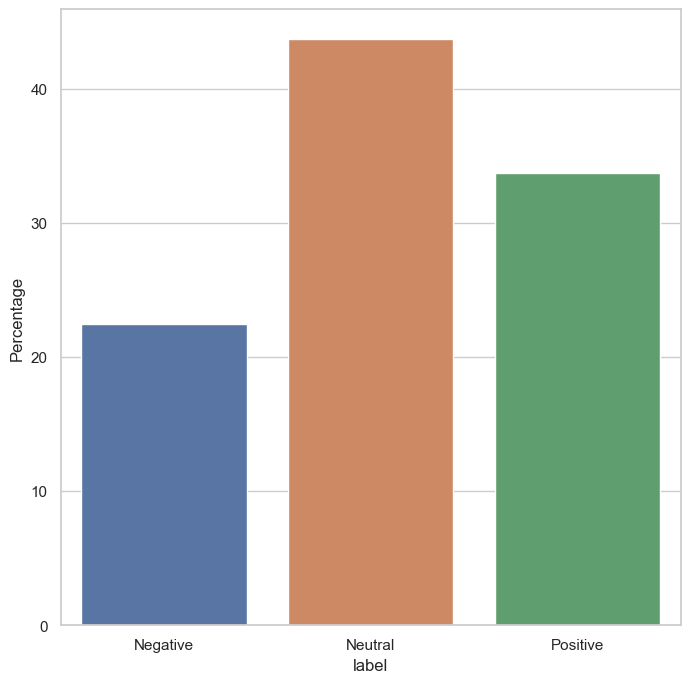

In [62]:
fig, ax = plt.subplots(figsize = (8, 8))

counts = comments_summary.label.value_counts(normalize = True) * 100

sns.barplot(x = counts.index, y = counts, ax=ax)

ax.set_xticklabels(['Negative', 'Neutral', 'Positive'])
ax.set_ylabel("Percentage")

plt.show()